# 🩹 Wound Classification - Improved Training (V2)

## Improvements over V1:
- ✅ **Stronger data augmentation** to reduce overfitting
- ✅ **Early stopping** to prevent overfitting
- ✅ **Higher dropout** (0.5 instead of 0.3)
- ✅ **Lower learning rate** for better convergence
- ✅ **Test evaluation** included
- ✅ **Frozen backbone** option for transfer learning

---

## Cell 1: Imports

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
from torchvision import transforms, datasets, models

# Check device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   Running on CPU (will be slower)")

✅ Using device: cpu
   Running on CPU (will be slower)


## Cell 2: Configuration ⚙️

### 👇 EDIT SETTINGS HERE! 👇

In [2]:
# =============================================================================
# ⚙️ CONFIGURATION - EDIT HERE!
# =============================================================================

# 👇👇👇 TRAINING SETTINGS 👇👇👇
NUM_EPOCHS = 50           # Maximum epochs (early stopping may stop sooner)
PATIENCE = 10             # Stop if no improvement for this many epochs
BATCH_SIZE = 32
LEARNING_RATE = 5e-5      # Lower LR for better convergence (was 1e-4)
DROPOUT_RATE = 0.5        # Higher dropout to reduce overfitting (was 0.3)
FREEZE_BACKBONE = True    # Freeze early layers (helps with small datasets)
# 👆👆👆 TRAINING SETTINGS 👆👆👆

# Paths (your PC)
CROPPED_DATA_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\cropped_classification_data"
MODEL_SAVE_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models"

# Image settings
IMAGE_SIZE = 224

# Create directories
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print("="*60)
print("⚙️ CONFIGURATION (Improved V2)")
print("="*60)
print(f"   Max Epochs:      {NUM_EPOCHS}")
print(f"   Early Stopping:  {PATIENCE} epochs patience")
print(f"   Batch size:      {BATCH_SIZE}")
print(f"   Learning rate:   {LEARNING_RATE}")
print(f"   Dropout:         {DROPOUT_RATE}")
print(f"   Freeze backbone: {FREEZE_BACKBONE}")
print(f"   Device:          {DEVICE}")
print("="*60)

⚙️ CONFIGURATION (Improved V2)
   Max Epochs:      50
   Early Stopping:  10 epochs patience
   Batch size:      32
   Learning rate:   5e-05
   Dropout:         0.5
   Freeze backbone: True
   Device:          cpu


## Cell 3: Data Transforms (Stronger Augmentation)

In [3]:
def get_train_transforms():
    """
    Training transforms with STRONGER augmentation to reduce overfitting.
    """
    return transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(IMAGE_SIZE),
        
        # Flips
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        
        # Rotation (stronger)
        transforms.RandomRotation(degrees=45),
        
        # Color augmentation (stronger)
        transforms.ColorJitter(
            brightness=0.4,
            contrast=0.4,
            saturation=0.4,
            hue=0.15
        ),
        
        # Affine transforms
        transforms.RandomAffine(
            degrees=15,
            translate=(0.15, 0.15),
            scale=(0.85, 1.15),
            shear=10
        ),
        
        # Random perspective
        transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
        
        # Random grayscale (helps generalization)
        transforms.RandomGrayscale(p=0.1),
        
        # Gaussian blur
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        
        # To tensor and normalize
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        
        # Random erasing (cutout)
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    ])

def get_val_transforms():
    """Validation/Test transforms (no augmentation)."""
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

print("✅ Transforms defined (with stronger augmentation)!")

✅ Transforms defined (with stronger augmentation)!


## Cell 4: Load All Datasets (Train + Validation + Test)

In [4]:
print("📂 Loading datasets...\n")

# Training data
train_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'Train'),
    transform=get_train_transforms()
)

# Validation data
val_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'Valid'),
    transform=get_val_transforms()
)

# Test data
test_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'test'),
    transform=get_val_transforms()
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Count class distribution
train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

print("="*60)
print("📊 DATASET SUMMARY")
print("="*60)
print(f"   Classes: {train_dataset.classes}")
print(f"")
print(f"   Training:    {len(train_dataset):,} images")
for cls_idx, cls_name in enumerate(train_dataset.classes):
    print(f"      - {cls_name}: {class_counts[cls_idx]:,}")
print(f"")
print(f"   Validation:  {len(val_dataset):,} images")
print(f"   Test:        {len(test_dataset):,} images")
print("="*60)

📂 Loading datasets...

📊 DATASET SUMMARY
   Classes: ['infected', 'non-infected']

   Training:    700 images
      - infected: 350
      - non-infected: 350

   Validation:  170 images
   Test:        152 images


## Cell 5: Create Improved EfficientNet Model

In [5]:
def create_improved_classifier(num_classes=2, dropout_rate=0.5, freeze_backbone=True):
    """
    Create EfficientNet-B0 with improvements:
    - Higher dropout
    - Option to freeze backbone (transfer learning)
    - Better classifier head
    """
    # Load pretrained model
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)
    
    # Freeze backbone layers (helps prevent overfitting on small datasets)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
        # Unfreeze last 2 blocks for fine-tuning
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        print("   🔒 Backbone frozen (except last 2 blocks)")
    
    # Replace classifier head with better regularization
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate, inplace=True),
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(256),
        nn.Dropout(p=dropout_rate),
        nn.Linear(256, num_classes)
    )
    
    return model

# Create model
print("🏗️ Creating Improved EfficientNet-B0 model...")
model = create_improved_classifier(
    num_classes=2, 
    dropout_rate=DROPOUT_RATE, 
    freeze_backbone=FREEZE_BACKBONE
)
model = model.to(DEVICE)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model created!")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

🏗️ Creating Improved EfficientNet-B0 model...
   🔒 Backbone frozen (except last 2 blocks)

✅ Model created!
   Total parameters:     4,336,510
   Trainable parameters: 1,458,354 (33.6%)


## Cell 6: Training Function with Early Stopping

In [6]:
class EarlyStopping:
    """Early stopping to prevent overfitting."""
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, val_acc):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0
        return self.early_stop


def train_model_v2(model, train_loader, val_loader, num_epochs, patience, save_path):
    """
    Improved training with early stopping and better monitoring.
    """
    criterion = nn.CrossEntropyLoss()
    
    # Only optimize trainable parameters
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=LEARNING_RATE, 
        weight_decay=1e-3  # Stronger weight decay
    )
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-7
    )
    
    # Early stopping
    early_stopping = EarlyStopping(patience=patience)
    
    # Mixed precision
    use_amp = DEVICE.type == 'cuda'
    scaler = GradScaler('cuda') if use_amp else None
    
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    
    print(f"\n{'='*60}")
    print(f"🚀 STARTING IMPROVED TRAINING")
    print(f"   Max Epochs: {num_epochs} | Early Stopping Patience: {patience}")
    print(f"{'='*60}\n")
    
    for epoch in range(num_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        
        # ===================== TRAINING =====================
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            
            optimizer.zero_grad()
            
            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            train_loss += loss.item()
            
            if (batch_idx + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{num_epochs} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")
        
        train_loss /= len(train_loader)
        train_acc = 100. * train_correct / train_total
        
        # ===================== VALIDATION =====================
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        # Update scheduler based on validation accuracy
        scheduler.step(val_acc)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Calculate gap (overfitting indicator)
        gap = train_acc - val_acc
        gap_status = "🟢" if gap < 5 else "🟡" if gap < 10 else "🔴"
        
        # Print epoch summary
        print(f"\n📊 Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.2e}")
        print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
        print(f"   Gap:   {gap:.1f}% {gap_status}")
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
                'train_acc': train_acc,
            }, save_path)
            print(f"   ✅ NEW BEST MODEL! (Val Acc: {val_acc:.2f}%)")
        
        # Check early stopping
        if early_stopping(val_acc):
            print(f"\n⚠️ Early stopping triggered after {epoch+1} epochs!")
            print(f"   No improvement for {patience} epochs.")
            break
        
        print("-" * 60)
    
    print(f"\n{'='*60}")
    print(f"🏁 TRAINING COMPLETE!")
    print(f"{'='*60}")
    print(f"   Epochs trained:          {epoch+1}")
    print(f"   Best Validation Accuracy: {best_acc:.2f}%")
    print(f"   Model saved to: {save_path}")
    
    return history, best_acc

print("✅ Training function defined (with early stopping)!")

✅ Training function defined (with early stopping)!


---
# 🏃 Cell 7: START TRAINING!
---

In [7]:
# Path to save the model
model_save_path = os.path.join(MODEL_SAVE_DIR, 'classification_efficientnet_v2.pth')

# Train the model!
history, best_accuracy = train_model_v2(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=model_save_path
)

print(f"\n🏆 Training Best Accuracy: {best_accuracy:.2f}%")


🚀 STARTING IMPROVED TRAINING
   Max Epochs: 50 | Early Stopping Patience: 10

  Epoch 1/50 | Batch 20/21 | Loss: 0.8083

📊 Epoch [1/50] | LR: 5.00e-05
   Train: Loss=0.8102, Acc=50.89%
   Val:   Loss=0.6590, Acc=65.88%
   Gap:   -15.0% 🟢
   ✅ NEW BEST MODEL! (Val Acc: 65.88%)
------------------------------------------------------------
  Epoch 2/50 | Batch 20/21 | Loss: 0.8500

📊 Epoch [2/50] | LR: 5.00e-05
   Train: Loss=0.7338, Acc=57.89%
   Val:   Loss=0.6215, Acc=70.00%
   Gap:   -12.1% 🟢
   ✅ NEW BEST MODEL! (Val Acc: 70.00%)
------------------------------------------------------------
  Epoch 3/50 | Batch 20/21 | Loss: 0.5538

📊 Epoch [3/50] | LR: 5.00e-05
   Train: Loss=0.6998, Acc=60.57%
   Val:   Loss=0.6004, Acc=70.00%
   Gap:   -9.4% 🟢
------------------------------------------------------------
  Epoch 4/50 | Batch 20/21 | Loss: 0.6302

📊 Epoch [4/50] | LR: 5.00e-05
   Train: Loss=0.6744, Acc=62.80%
   Val:   Loss=0.5932, Acc=71.76%
   Gap:   -9.0% 🟢
   ✅ NEW BEST MODEL! (

## Cell 8: Plot Training History

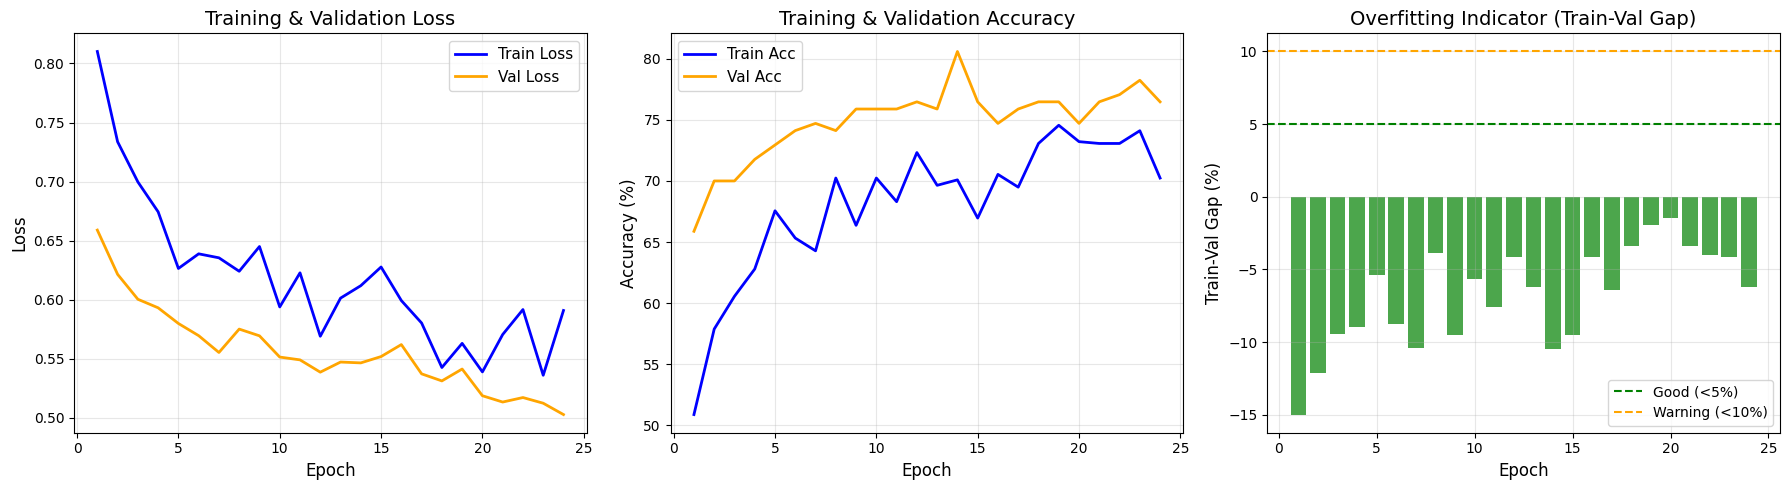

📊 Training history saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'orange', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 'orange', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Gap plot (overfitting indicator)
gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
colors = ['green' if g < 5 else 'orange' if g < 10 else 'red' for g in gap]
axes[2].bar(epochs_range, gap, color=colors, alpha=0.7)
axes[2].axhline(y=5, color='green', linestyle='--', label='Good (<5%)')
axes[2].axhline(y=10, color='orange', linestyle='--', label='Warning (<10%)')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Train-Val Gap (%)', fontsize=12)
axes[2].set_title('Overfitting Indicator (Train-Val Gap)', fontsize=14)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_history_v2.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Training history saved!")

---
# 🧪 Cell 9: EVALUATE ON TEST SET

This is the **final evaluation** on data the model has never seen!

---

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load the best model
print("📂 Loading best model for testing...")
checkpoint = torch.load(model_save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(f"   Loaded model from epoch {checkpoint['epoch']+1}")
print(f"   Validation accuracy was: {checkpoint['val_acc']:.2f}%")

# Evaluate on test set
print(f"\n🧪 Evaluating on TEST set ({len(test_dataset)} images)...")

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate accuracy
test_accuracy = 100 * np.mean(all_preds == all_labels)

print(f"\n{'='*60}")
print(f"🧪 TEST SET RESULTS")
print(f"{'='*60}")
print(f"\n   🎯 TEST ACCURACY: {test_accuracy:.2f}%\n")

# Classification report
class_names = test_dataset.classes
print("📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 16})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix (Test Accuracy: {test_accuracy:.2f}%)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print(f"\n💾 Confusion matrix saved!")

---
# ✅ Cell 10: Final Summary
---

In [ ]:
print("\n" + "="*60)
print("🏆 FINAL SUMMARY")
print("="*60)
print(f"\n   📊 Training Results:")
print(f"      - Best Validation Accuracy: {best_accuracy:.2f}%")
print(f"      - Epochs trained: {len(history['train_loss'])}")
print(f"")
print(f"   🧪 Test Results:")
print(f"      - Test Accuracy: {test_accuracy:.2f}%")
print(f"")
print(f"   📁 Files Saved:")
print(f"      - Model: {model_save_path}")
print(f"      - Training history: training_history_v2.png")
print(f"      - Confusion matrix: confusion_matrix.png")
print("="*60)

# Compare with validation
diff = test_accuracy - best_accuracy
if abs(diff) < 2:
    print("\n✅ Test accuracy is close to validation - model generalizes well!")
elif diff < -2:
    print("\n⚠️ Test accuracy is lower than validation - some overfitting may remain.")
else:
    print("\n🎉 Test accuracy is higher than validation - great generalization!")

---
# 🔮 Cell 11: Test on Single Image (Optional)
---

In [ ]:
def predict_single_image(image_path, model, device):
    """Predict on a single wound image."""
    
    # Load and transform image
    image = Image.open(image_path).convert('RGB')
    transform = get_val_transforms()
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs[0, pred_class].item()
    
    class_names = ['infected', 'non-infected']
    prediction = class_names[pred_class]
    
    # Display
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    color = 'red' if prediction == 'infected' else 'green'
    plt.title(f'Prediction: {prediction.upper()}\nConfidence: {confidence*100:.1f}%', 
              fontsize=16, fontweight='bold', color=color)
    plt.axis('off')
    plt.show()
    
    print(f"\n🩹 Prediction: {prediction.upper()}")
    print(f"   Confidence: {confidence*100:.1f}%")
    print(f"   Infected probability: {probs[0,0].item()*100:.1f}%")
    print(f"   Non-infected probability: {probs[0,1].item()*100:.1f}%")
    
    return prediction, confidence

# ===== UNCOMMENT AND EDIT TO TEST ON YOUR IMAGE =====
# test_image = r"C:\path\to\your\wound_image.jpg"
# prediction, confidence = predict_single_image(test_image, model, DEVICE)

print("✅ Single image prediction function ready!")
print("\n📝 Usage:")
print('   predict_single_image(r"C:\\path\\to\\image.jpg", model, DEVICE)')